---
title: BioSkin Technical Note
execute:
  echo: true
format:
  html:
    code-fold: false
---

This notebook documents a compact BioSkin workflow for mapping biophysical skin parameters to visible and near-infrared spectral reflectance. The emphasis is on the forward decoder provided by BioSkin to generate spectral reflectance.

# Methodological Overview


<style>
.flow-diagram {
  display: flex;
  flex-wrap: wrap;
  align-items: stretch;
  gap: 0.55rem;
  margin: 1rem 0 1.25rem;
}
.flow-node {
  flex: 1 1 10rem;
  min-width: 9rem;
  border: 1px solid #d0d7de;
  border-radius: 6px;
  padding: 0.65rem 0.75rem;
  background: #f8fafc;
}
.flow-node strong {
  display: block;
  margin-bottom: 0.2rem;
  color: #1f2937;
}
.flow-node span {
  display: block;
  color: #4b5563;
  font-size: 0.9rem;
  line-height: 1.25;
}
.flow-arrow {
  align-self: center;
  color: #667085;
  font-weight: 700;
  padding: 0 0.1rem;
}
.flow-loop {
  margin-top: 0.25rem;
  color: #667085;
  font-size: 0.9rem;
}
@media (max-width: 700px) {
  .flow-diagram { display: block; }
  .flow-node { margin: 0.45rem 0; }
  .flow-arrow { text-align: center; padding: 0.1rem 0; }
}
</style>

## Forward Process

The full forward process starts from biophysical skin parameters, estimates spectral reflectance with a human skin model, and renders the spectrum into a color representation.

<div class="flow-diagram" aria-label="Forward BioSkin process">
  <div class="flow-node"><strong>Biophysical skin parameters</strong><span>Melanin, blood, thickness, oxygenation, melanin type ratio</span></div>
  <div class="flow-arrow">&rarr;</div>
  <div class="flow-node"><strong>Human skin model</strong><span>Monte Carlo light transport</span></div>
  <div class="flow-arrow">&rarr;</div>
  <div class="flow-node"><strong>Spectral reflectance</strong><span>Reflectance by wavelength</span></div>
  <div class="flow-arrow">&rarr;</div>
  <div class="flow-node"><strong>Color representation</strong><span>RGB / CIE LAB</span></div>
</div>

### Notes

- **Skin parameters:** melanin volume fraction, blood volume fraction, thickness, hemoglobin oxygenation, and melanin type ratio.
- **Human skin model:** brute-force Monte Carlo random walks inside the skin.
- **Output spectrum:** reflectance as a function of wavelength.

## Inverse Process

The inverse process maps an observed color back to latent skin parameters. BioSkin implements this as an encoder-decoder cycle in which the encoder estimates parameters from RGB and the decoder generates the spectral reflectance from skin parameters.

<div class="flow-diagram" aria-label="BioSkin encoder-decoder cycle">
  <div class="flow-node"><strong>RGB observation</strong><span>Measured or rendered skin color</span></div>
  <div class="flow-arrow">&rarr; Encoder &rarr;</div>
  <div class="flow-node"><strong>Biophysical skin parameters</strong><span>Estimated latent parameters</span></div>
  <div class="flow-arrow">&rarr; Decoder &rarr;</div>
  <div class="flow-node"><strong>Spectral reflectance</strong><span>Decoded spectrum</span></div>
  <div class="flow-arrow">&rarr; Render &rarr;</div>
  <div class="flow-node"><strong>RGB reconstruction</strong><span>Closed-cycle color output</span></div>
</div>
<div class="flow-loop">The encoder-decoder cycle compares the reconstructed RGB with the observed RGB while retaining the decoded reflectance spectrum.</div>

### Notes

- **Decoder:** maps skin parameters to spectral reflectance, approximating the Monte Carlo simulation.
- **Renderer:** converts spectral reflectance into RGB.
- **Encoder:** maps RGB back to estimated skin parameters.
- This forms an inverse modeling framework for estimating biological skin parameters from color observations.

## Compact Summary

```text
Forward:
Biophysical skin parameters
    -> human skin model / brute-force Monte Carlo
    -> spectral reflectance
    -> RGB / CIE LAB

Inverse:
RGB
    -> encoder
    -> biophysical skin parameters
    -> decoder
    -> spectral reflectance
    -> render
    -> RGB
```


# Spectral Reflectance Generation

The following cell records the BioSkin parameter names and their reported ranges. The regular range excludes localized effects such as rashes or spots, while the plausible and full ranges provide broader limits for parameter exploration.

In [1]:
import pandas as pd

SKIN_PROPS = [
    "Melanin",
    "Hemoglobin",
    "Thickness",
    "Blood oxygenation",
    "Melanin type ratio",
    "Occlusion",
]

# Regular range, excluding localized effects such as rashes or spots.
REGULAR_SKIN_MIN_VALUES = [0.005, 0.001, 0.005, 0.6, 0.72, 0.001]
REGULAR_SKIN_MAX_VALUES = [0.40, 0.0225, 0.025, 0.8, 0.76, 1.0]

# Plausible range.
SKIN_MIN_VALUES = [0.001, 0.001, 0.001, 0.001, 0.001, 0.001]
SKIN_MAX_VALUES = [0.45, 0.25, 0.035, 1.0, 1.0, 1.0]

# Full parameter range.
MIN_PROP_VALUES = [0.001, 0.001, 0.001, 0.001, 0.001, 0.001]
MAX_PROP_VALUES = [1.0, 1.0, 0.035, 1.0, 1.0, 1.0]

parameter_ranges = pd.DataFrame(
    {
        "Parameter": SKIN_PROPS,
        "Regular minimum": REGULAR_SKIN_MIN_VALUES,
        "Regular maximum": REGULAR_SKIN_MAX_VALUES,
        "Plausible minimum": SKIN_MIN_VALUES,
        "Plausible maximum": SKIN_MAX_VALUES,
        "Full minimum": MIN_PROP_VALUES,
        "Full maximum": MAX_PROP_VALUES,
    }
)

parameter_ranges

,Parameter,Regular minimum,Regular maximum,Plausible minimum,Plausible maximum,Full minimum,Full maximum
0,Melanin,0.005,0.4000,0.001,0.450,0.001,1.000
1,Hemoglobin,0.001,0.0225,0.001,0.250,0.001,1.000
2,Thickness,0.005,0.0250,0.001,0.035,0.001,0.035
3,Blood oxygenation,0.600,0.8000,0.001,1.000,0.001,1.000
4,Melanin type ratio,0.720,0.7600,0.001,1.000,0.001,1.000
5,Occlusion,0.001,1.0000,0.001,1.000,0.001,1.000


> **Remark.** BioSkin does not distribute the original Monte Carlo skin model used to synthesize its training spectra. Instead, it provides a pretrained decoder that maps skin parameters directly to spectral reflectance. This notebook evaluates the decoder using four illustrative skin-parameter vectors.

In [11]:
from bioskin.bioskin import BioSkinInference
%matplotlib inline
import matplotlib.pyplot as plt
import torch

# BioSkin imports Matplotlib with the non-interactive Agg backend;
# switch back to the notebook inline backend so plt.show() renders here.
plt.switch_backend("module://matplotlib_inline.backend_inline")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 512000

model_path = "/Users/hjh/PhD/Tina/BioSkin/pretrained_models/" # Change this to your local path where the pretrained model is stored.
model_name = "BioSkinAO"

# Load the encoder-decoder model for skin reflectance generation.
bio_skin = BioSkinInference(model_path + model_name, device=device, batch_size=batch_size)

# Define four illustrative input parameter vectors.
skin_case_names = [
    "Light, low blood",
    "Light, higher blood",
    "Medium melanin",
    "High melanin",
]

skin_props = torch.tensor(
    [
        [0.03, 0.005, 0.010, 0.75, 0.74, 0.10],
        [0.03, 0.020, 0.010, 0.70, 0.74, 0.10],
        [0.15, 0.010, 0.012, 0.70, 0.74, 0.10],
        [0.35, 0.010, 0.012, 0.70, 0.74, 0.10],
    ],
    dtype=torch.float32,
    device=device,
)

# Columns: melanin volume fraction, blood volume fraction, thickness,
# blood oxygenation, melanin type ratio, and occlusion.

# Generate spectral reflectance with the pretrained decoder.
# Visible range: 380-780 nm, 2 nm each step.
# Near-infrared range: 780-1000 nm, 2 nm each step.
with torch.no_grad():
    ref_vis, ref_vis_rgb, ref_ir, ref_ir_avg = bio_skin.skin_props_to_reflectance(skin_props)

Loading model in /Users/hjh/PhD/Tina/BioSkin/pretrained_models/BioSkinAO
Loading Training Parameters
{'color_mode': 'spectral', 'param_mode': 'linear', 'network_structure': 2, 'exposure_aware': True, 'loss_mode': 'visible_range', 'loss_params': 'MSE', 'loss_color': 'sam', 'loss_color_full_cycle': 'l1', 'w_p': 1.0, 'w_e': 1.0, 'w_a': 1.0, 'w_full': 1.0, 'n_epochs': 500, 'learning_rate': 0.0001, 'learning_rate_update': 10, 'batch_size': 256, 'writing_rate': 1, 'D_rgb': 3, 'H_enc': 70, 'H_dec': 512, 'wavelength_begin': 380, 'wavelength_end': 1000, 'spectral_resolution': 2, 'D_skin': 5, 'D_spec': 310, 'visible_range_limit': 200}
Device: cpu


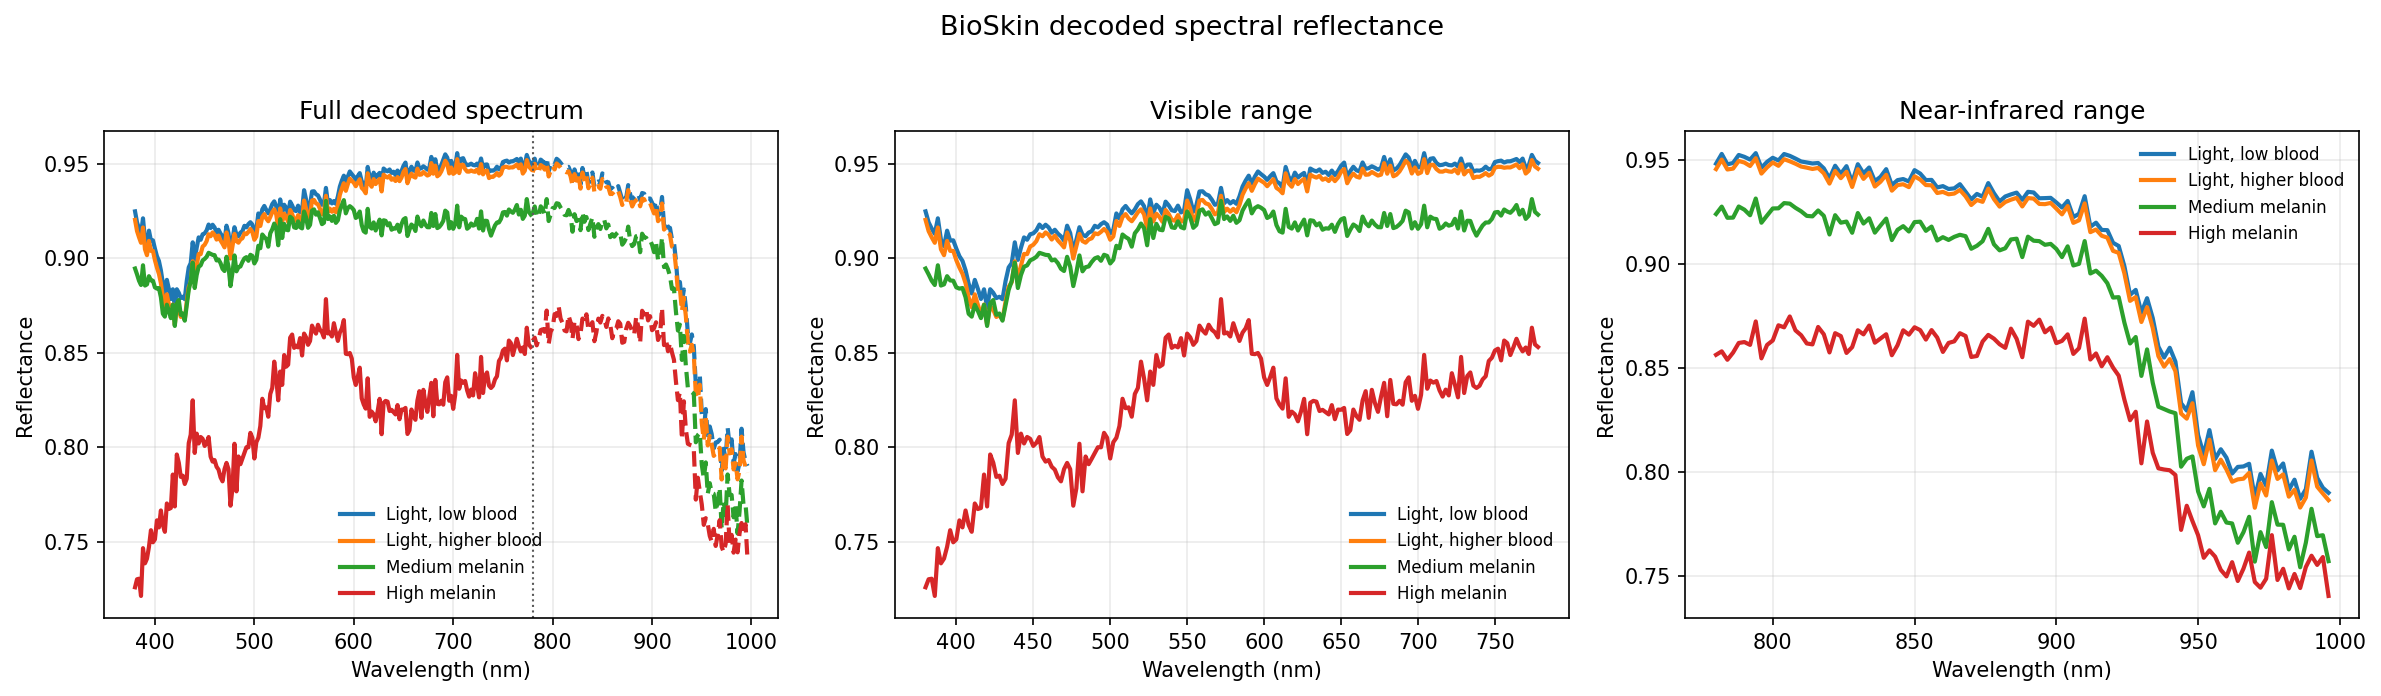

In [12]:
# Plot decoded reflectance in the visible and near-infrared ranges.
visible_wavelengths = 380 + 2 * torch.arange(ref_vis.shape[1], device=ref_vis.device)
infrared_wavelengths = 780 + 2 * torch.arange(ref_ir.shape[1], device=ref_ir.device)

visible_reflectance = ref_vis.detach().cpu().numpy()
infrared_reflectance = ref_ir.detach().cpu().numpy()
visible_wavelengths = visible_wavelengths.detach().cpu().numpy()
infrared_wavelengths = infrared_wavelengths.detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), dpi=150)
fig.suptitle("BioSkin decoded spectral reflectance", y=1.02, fontsize=13)

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for case_name, visible_curve, infrared_curve, color in zip(
    skin_case_names, visible_reflectance, infrared_reflectance, colors
):
    axes[0].plot(visible_wavelengths, visible_curve, color=color, linewidth=2, label=case_name)
    axes[0].plot(infrared_wavelengths, infrared_curve, color=color, linewidth=2, linestyle="--")
    axes[1].plot(visible_wavelengths, visible_curve, color=color, linewidth=2, label=case_name)
    axes[2].plot(infrared_wavelengths, infrared_curve, color=color, linewidth=2, label=case_name)

axes[0].axvline(780, color="0.35", linestyle=":", linewidth=1)
axes[0].set_title("Full decoded spectrum")
axes[0].set_xlabel("Wavelength (nm)")
axes[0].set_ylabel("Reflectance")

axes[1].set_title("Visible range")
axes[1].set_xlabel("Wavelength (nm)")
axes[1].set_ylabel("Reflectance")

axes[2].set_title("Near-infrared range")
axes[2].set_xlabel("Wavelength (nm)")
axes[2].set_ylabel("Reflectance")

for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()


The figure reports the decoded reflectance for four illustrative skin-parameter vectors. The left panel shows the visible and near-infrared spectra together, with dashed lines marking the near-infrared portions and the vertical line marking the 780 nm transition. The middle and right panels separate the two wavelength ranges to make local spectral structure easier to inspect.